In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
import tensorflow as tf

from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer

from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import roc_auc_score,accuracy_score,roc_curve,classification_report 
%matplotlib inline

# load and perform EDA for training the model 

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.tail()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
159566,ffe987279560d7ff,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,ffea4adeee384e90,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,ffee36eab5c267c9,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,fff125370e4aaaf3,And it looks like it was actually you who put ...,0,0,0,0,0,0
159570,fff46fc426af1f9a,"""\nAnd ... I really don't think you understand...",0,0,0,0,0,0


In [5]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


In [7]:
X = df.iloc[:,2:].sum()
X

toxic            15294
severe_toxic      1595
obscene           8449
threat             478
insult            7877
identity_hate     1405
dtype: int64

In [8]:
rowsums = df.iloc[:,2:].sum(axis=1)
rowsums

0         0
1         0
2         0
3         0
4         0
         ..
159566    0
159567    0
159568    0
159569    0
159570    0
Length: 159571, dtype: int64

In [9]:
no_label_count = 0

for i, count in rowsums.items():
    if count == 0:
        no_label_count+=1
print('Total number of comments:', len(df))
print('Total number of comments without labels:',no_label_count)
print('Total labels:',X.sum())
    

Total number of comments: 159571
Total number of comments without labels: 143346
Total labels: 35098


C:\Users\yadun\AppData\Local\Temp\ipykernel_22540\2630937339.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= X.index, y=X.values,


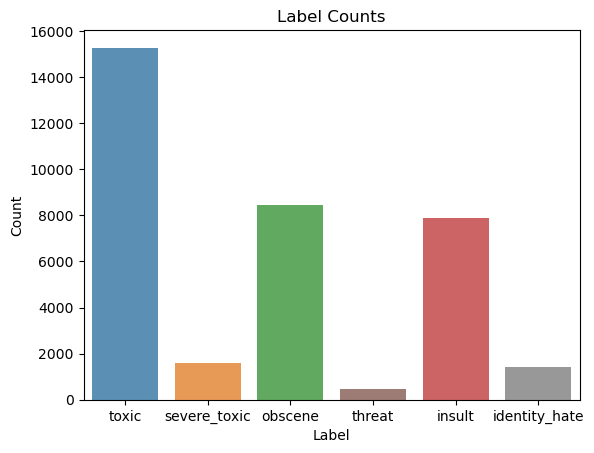

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')
# cols = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']
ax = sns.barplot(x= X.index, y=X.values,
alpha=0.8, palette=['tab:blue', 'tab:orange','tab:green', 'tab:brown', 'tab:red', 'tab:grey'])
# train[cols].sum().plot(kind='bar')
plt.show()

## Data Preprocessing 

In [11]:
df = df.drop(columns = ['id'],axis= 1)

In [12]:
df

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0
...,...,...,...,...,...,...,...
159566,""":::::And for the second time of asking, when ...",0,0,0,0,0,0
159567,You should be ashamed of yourself \n\nThat is ...,0,0,0,0,0,0
159568,"Spitzer \n\nUmm, theres no actual article for ...",0,0,0,0,0,0
159569,And it looks like it was actually you who put ...,0,0,0,0,0,0


In [13]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\yadun\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [14]:
stopwords_set = set(stopwords.words('english'))

def remove_stopwords(text):  # Fixed parameter name from 'test' to 'text'
    no_stopword_text = [w for w in text.split() if not w in stopwords_set]  # Added parentheses to split() and fixed variable name
    return " ".join(no_stopword_text)  # Fixed variable name from 'no_stopword_test' to 'no_stopword_text'

def clean_text(text):
    text = text.lower()
    text = re.sub(r"what's","what is",text)
    text = re.sub(r"\'s"," ",text)
    text = re.sub(r"can't","can not",text)
    text = re.sub(r"n't","not",text)
    text = re.sub(r"i'm","i am ",text)
    text = re.sub(r"\'re"," are", text)
    text = re.sub(r"\'d","would", text)  
    text = re.sub(r"\'ll","will", text)
    text = re.sub(r"\'scuse","excuse", text)
    text = re.sub('\W',' ' , text)
    text = re.sub('\s+',' ' , text)
    text = text.strip(' ')  # Fixed: strip() should remove spaces, not empty string
    return text

stemmer = SnowballStemmer('english')
def stemming(sentence):
    stemmed_sentence = ""
    for word in sentence.split():
        stemmed_word = stemmer.stem(word)
        stemmed_sentence +=stemmed_word+" "

    stemmed_sentance = stemmed_sentence.strip()
    return stemmed_sentance    

In [15]:
df['comment_text'] = df['comment_text'].apply(lambda x : remove_stopwords(x))
df['comment_text'] = df['comment_text'].apply(lambda x : clean_text(x))
df['comment_text'] = df['comment_text'].apply(lambda x : stemming(x))  
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explan whi edit made usernam hardcor metallica...,0,0,0,0,0,0
1,d aww he match background colour i am seem stu...,0,0,0,0,0,0
2,hey man i am realli tri edit war it guy consta...,0,0,0,0,0,0
3,more i can not make real suggest improv i wond...,0,0,0,0,0,0
4,you sir hero ani chanc rememb page that on,0,0,0,0,0,0


In [16]:
X = df['comment_text']
Y = df.drop(columns=['comment_text'],axis =1)

In [17]:
x_train , x_test , y_train , y_test = train_test_split(X,Y, test_size = 0.2 ,random_state = 42)

# Used pipeline as model implementation

## Model Pipeline Building

In [25]:
def run_pipeline(pipeline, x_train , x_test , y_train , y_test):
    pipeline.fit(x_train,y_train)
    predictions = pipeline.predict(x_test)
    predict_probs = pipeline.predict_proba(x_test)
    print ('roc_curve:' ,roc_auc_score(y_test,predict_probs))
    print ('accuracy:', accuracy_score(y_test,predictions))
    print ('Classification report')
    print (classification_report(y_test,predictions , target_names = y_train.columns))

In [26]:
NB_pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(stop_words= 'english')),
    ('model',OneVsRestClassifier(MultinomialNB()))
])

LR_pipeline = Pipeline([
    ('tfidf',TfidfVectorizer(stop_words= 'english')),
    ('model',OneVsRestClassifier(LogisticRegression()))
])

In [27]:
run_pipeline(NB_pipeline,x_train , x_test , y_train , y_test)

roc_curve: 0.8604509894561824
accuracy: 0.8997963340122199
Classification report
               precision    recall  f1-score   support

        toxic       0.99      0.19      0.31      3056
 severe_toxic       0.00      0.00      0.00       321
      obscene       0.98      0.11      0.20      1715
       threat       1.00      0.01      0.03        74
       insult       0.97      0.05      0.10      1614
identity_hate       0.00      0.00      0.00       294

    micro avg       0.98      0.12      0.22      7074
    macro avg       0.66      0.06      0.11      7074
 weighted avg       0.90      0.12      0.21      7074
  samples avg       0.02      0.01      0.01      7074



C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
run_pipeline(LR_pipeline,x_train , x_test , y_train , y_test)

roc_curve: 0.9788913897906442
accuracy: 0.9182202725990913
Classification report
               precision    recall  f1-score   support

        toxic       0.91      0.62      0.74      3056
 severe_toxic       0.58      0.28      0.38       321
      obscene       0.91      0.64      0.75      1715
       threat       0.62      0.14      0.22        74
       insult       0.82      0.50      0.62      1614
identity_hate       0.71      0.16      0.27       294

    micro avg       0.87      0.56      0.68      7074
    macro avg       0.76      0.39      0.50      7074
 weighted avg       0.86      0.56      0.67      7074
  samples avg       0.06      0.05      0.05      7074



C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\yadun\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# Model Evaluation 
## Choosed the LogisticRegression model as the best giving Accuracy of 0.91 compared to MultinomialNB wit 0.89

# Testing the data model in the test.csv for the prediction 

In [31]:
tf = pd.read_csv("test.csv")
tf.head()

,id,comment_text
0,00001cee341fdb12,Yo bitch Ja Rule is more succesful then you'll...
1,0000247867823ef7,== From RfC == \n\n The title is fine as it is...
2,00013b17ad220c46,""" \n\n == Sources == \n\n * Zawe Ashton on Lap..."
3,00017563c3f7919a,":If you have a look back at the source, the in..."
4,00017695ad8997eb,I don't anonymously edit articles at all.


# Data preprocessing for prediction 

In [33]:
tf['comment_text'] = tf['comment_text'].apply(lambda x : remove_stopwords(x))
tf['comment_text'] = tf['comment_text'].apply(lambda x : clean_text(x))
tf['comment_text'] = tf['comment_text'].apply(lambda x : stemming(x))  
tf.head()

,id,comment_text
0,00001cee341fdb12,yo bitch ja rule succes ever what hate sad mof...
1,0000247867823ef7,from rfc the titl fine is imo
2,00013b17ad220c46,sourc zaw ashton lapland
3,00017563c3f7919a,if look back sourc inform i updat correct form...
4,00017695ad8997eb,i anonym edit articl all


# Direct prediction to the  comment text column

In [34]:
predictions = LR_pipeline.predict(
    tf['comment_text']
)

In [35]:
predictions

array([[1, 0, 1, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       ...,
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [1, 0, 1, 0, 0, 0]])

In [37]:
cols = [
'toxic',
'severe_toxic',
'obscene',
'threat',
'insult',
'identity_hate'
]

pred_df = pd.DataFrame(
    predictions,
    columns=cols
)

# concatinating the predicted columns to the actual dataset 

In [38]:
result = pd.concat(
    [tf,pred_df],
    axis=1
)

In [39]:
result

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,00001cee341fdb12,yo bitch ja rule succes ever what hate sad mof...,1,0,1,0,1,0
1,0000247867823ef7,from rfc the titl fine is imo,0,0,0,0,0,0
2,00013b17ad220c46,sourc zaw ashton lapland,0,0,0,0,0,0
3,00017563c3f7919a,if look back sourc inform i updat correct form...,0,0,0,0,0,0
4,00017695ad8997eb,i anonym edit articl all,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...
153159,fffcd0960ee309b5,total agre stuff noth too long crap,1,0,0,0,0,0
153160,fffd7a9a6eb32c16,throw field home plate doe get faster throw cu...,0,0,0,0,0,0
153161,fffda9e8d6fafa9e,okinotorishima categori i see chang agre more ...,0,0,0,0,0,0
153162,fffe8f1340a79fc2,one found nation eu germani law return quit si...,0,0,0,0,0,0


# Saving the model 

In [40]:
import joblib

joblib.dump(LR_pipeline, 'toxicity_pipeline.pkl')

print("Model saved successfully!")

Model saved successfully!
